In [1]:
import os
import sys
os.environ["CUDA_VISIBLE_DEVICES"]="5"
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import scanpy as sc
from tqdm.notebook import tqdm
from scipy.sparse import csr_matrix
import gc
import random
import warnings
warnings.filterwarnings("ignore")

from gANCHOR.utils import preprocess, data_scale, weighted_MSELoss, get_weight_matrix_pos
from gANCHOR.module1_cell_pretrain import pretrain_tf

from matplotlib import rcParams
rcParams['figure.figsize']=(10, 10)

In [2]:
device = torch.device('cuda')
output_dir = '../results'
fnres = 'result.csv'
batch_size = 128
scale_feature = 'gene' ## 'gene', 'cell', 'none'
scale_type = 'median' ## 'max', 'median', 'ndist'
ribosomal_process = 'remove' ## 'remove', 'regress_out', 'none'

lr = 1e-5
weight_decay = 0.0001
gamma = 0.2
n_hid = 128
patience = 2
combined_type = 'multiplicative'   ## 'sum' or 'multiplicative'
cell_pooling = 'attention'
jk = False
metric = 'f1' ## 'f1' or 'acc'
seed = 0
max_epoch = 5
print_freq = 1
drop_out = 0.2
use_data_batch = True
update_feature = 'loss'
a = 1  ## cell type annotation loss weight
b = 1  ## gene reconstruction loss weight
c = 0.35  ## data batch correction loss weight

In [3]:
m = sc.read_h5ad('/share/fsmresfiles/lyw/Singlecell/CART/2023/pretrain/regularized1/combined/T_CART_integrated_commongenes11232_final.h5ad')
m = preprocess(m, ribosomal=ribosomal_process)

m.obs['barcode'] = m.obs.index
m.obs.index = range(m.shape[0])

patient_info = pd.read_table("table/patient_features.txt", sep='\t', index_col = 0, header = 0, encoding = "utf-8")
patient_info['Response'].replace('Not mentioned', np.nan, inplace=True)

y, yuniques = pd.factorize(m.obs['cell_type'].values, sort=True)
y1, yuniques1 = pd.factorize(m.obs['batch_correct'].values, sort=True)
m.uns['type_yuniques'], m.uns['data_yuniques'] = list(yuniques), list(yuniques1)

m = data_scale(m, scale_feature=scale_feature, scale_type=scale_type)

m.X = csr_matrix(m.X)

batch_size_train = batch_size
batch_size_test = batch_size
train_test_table = pd.read_csv('table/Train_val_test.csv', index_col=0, header=0)
train_test_CART = train_test_table[train_test_table['data_type'] == 'CART']
train_patients = train_test_CART[train_test_CART['tr_val_test'] == 'train']['patient'].unique()
valid_patients = train_test_CART[train_test_CART['tr_val_test'] == 'val']['patient'].unique()
test_patients = train_test_CART[train_test_CART['tr_val_test'] == 'test']['patient'].unique()
train_idx = train_test_table[train_test_table['tr_val_test'] == 'train'].index.tolist()
val_idx = train_test_table[train_test_table['tr_val_test'] == 'val'].index.tolist()
test_idx = train_test_table[train_test_table['tr_val_test'] == 'test'].index.tolist()
dataloader_train_idx = torch.utils.data.DataLoader(dataset = train_idx, batch_size = batch_size_train, shuffle = True)
dataloader_val_idx = torch.utils.data.DataLoader(dataset = val_idx, batch_size = batch_size_test, shuffle = False)
dataloader_test_idx = torch.utils.data.DataLoader(dataset = test_idx, batch_size = batch_size_test, shuffle = False)
print("Cells:", len(train_idx), "train +", len(val_idx), "valid +", len(test_idx), "test")
print("Batches:", len(dataloader_train_idx), "train +", len(dataloader_val_idx), "valid +", len(dataloader_test_idx), "test")


min_gene_in_path = 5
H = pd.read_csv("table/mc3_gene_pathway_msig.c2.all.hg", index_col=0).astype('float')
H = H.loc[m.var.index]
H = H.loc[:, H.sum(axis=0) >= min_gene_in_path]
H = torch.Tensor(np.array(H)).float().to(device)
y = torch.Tensor(y).squeeze().long().to(device) 
y1 = torch.Tensor(y1).squeeze().long().to(device) 
nfts = torch.Tensor(np.identity(H.shape[0])).to(device)  
efts = torch.Tensor(np.identity(H.shape[1])).to(device)  

pos_weight = get_weight_matrix_pos(m.X, power=1/4)

m

Cells: 1156507 train + 320688 valid + 210372 test
Batches: 9036 train + 2506 valid + 1644 test


AnnData object with n_obs × n_vars = 1693727 × 11140
    obs: 'cell_type', 'assay', 'patient', 'sample_id', 'data_type', 'batch_correct', 'Response', 'sample_id_old', 'percent_ribo', 'n_counts', 'barcode'
    var: 'gene_median'
    uns: 'log1p', 'type_yuniques', 'data_yuniques'

------------------------------Epoch 0/4------------------------------
Train Loss: 1.0288 1.5384 0.0388 2.4013 f1: 0.4865
Updated Learning Rate: 1e-05
Valid Loss: 0.5551 0.5637 0.0045 2.1037 f1: 0.6356
updata_score: -0.5551; compare_score: -inf; need update!
Updating val loss: 0.635563; test loss: 0.420230; test f1: 0.638980
432m 43s
------------------------------Epoch 1/4------------------------------
Train Loss: 0.7498 1.0311 0.0094 2.0618 f1: 0.6455
Updated Learning Rate: 1e-05
Valid Loss: 0.5367 0.4834 0.0022 2.2159 f1: 0.6869
updata_score: -0.5367; compare_score: -0.5551; need update!
Updating val loss: 0.686853; test loss: 0.417628; test f1: 0.689440
863m 19s
------------------------------Epoch 2/4------------------------------
Train Loss: 0.7191 0.9633 0.0072 2.0551 f1: 0.6672
Updated Learning Rate: 1e-05
Valid Loss: 0.5189 0.4734 0.0023 2.1253 f1: 0.6915
updata_score: -0.5189; compare_score: -0.5367; need update!
Updating val loss: 0.691520; test loss: 0.411937; test f1: 0.69506

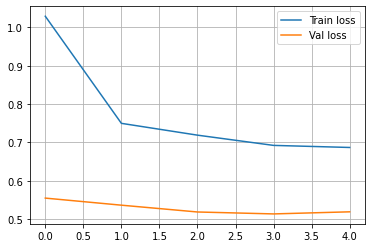

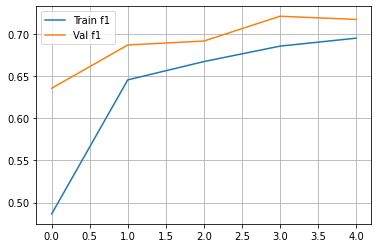

In [4]:
from datetime import date
from time import gmtime, strftime
saved_time = strftime("%Y-%m-%d_%H:%M:%S", gmtime())

fn = f'{output_dir}/gANCHOR_{saved_time}'
if os.path.exists(f'{fn}') is not True:
    os.mkdir(f'{fn}')
fres = open(f'{fn}/{fnres}', 'w')

fres.write(f'n_hid,lr,weight_decay,gamma,patience,seed,best_train_{metric},best_val_{metric},test_{metric},best_train_loss,best_val_loss,test_loss\n')
file = f'nhid{n_hid}_lr{lr}_wd{weight_decay}_gamma{gamma}_p{patience}_s{seed}_e{max_epoch}_a{a}_b{b}_c{c}_{saved_time}'    

model = pretrain_tf(H = H,
              type_yuniques = yuniques, 
              data_yuniques = yuniques1,
              n_input_gene = nfts.shape[1],
              n_hid = n_hid,
              jk = jk,
              combined_type = combined_type,
              dropout = drop_out,
              fc_dropout = drop_out,
              cell_pooling = cell_pooling,
              fn = f'{fn}/{file}',
              w_loss1 = a,
              w_loss2 = b,
              w_loss3 = c,
              metric = metric,
              seed = seed,
              use_data_batch = use_data_batch,
              mask_avg = False,
              )

model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
schedular = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=gamma, patience=patience)
type_cls_loss = torch.nn.CrossEntropyLoss(reduction='mean')
batch_cls_loss = torch.nn.CrossEntropyLoss(reduction='mean')
exp_pred_loss = weighted_MSELoss(reduction='mean')

model = model.fit_pretrain(nfts.float(), m, dataloader_train_idx, dataloader_val_idx, dataloader_test_idx, y, type_cls_loss, batch_cls_loss, exp_pred_loss, optimizer, schedular, device, max_epoch, 
                           print_freq=print_freq, update_feature=update_feature, data_batch_ids=y1, nonzero_loss_weights=pos_weight)

ckpt = torch.load(f'{fn}/{file}_pretrain.ckpt')
best_train_score = ckpt['best_train_score']
best_train_loss = ckpt['best_train_loss']
best_train_cm = ckpt['best_train_cm']
best_val_score = ckpt['best_val_score']
best_val_loss = ckpt['best_val_loss']
best_val_cm = ckpt['best_val_cm']
test_score = ckpt['test_score']
test_loss = ckpt['test_loss']
test_cm = ckpt['test_cm']
fres.write(f'{n_hid},{lr},{weight_decay},{gamma},{patience},{seed},{best_train_score},{best_val_score},{test_score},{best_train_loss},{best_val_loss},{test_loss}\n')
fres.close()

In [7]:

dataloader_all_idx = torch.utils.data.DataLoader(train_test_table.index.tolist(), batch_size=batch_size, shuffle=False)

model.eval()

with torch.no_grad():
    nfts_float = nfts.float()
    xe = model.HTa.mm(nfts_float)

model_cell_embed_list = []
model_gene_pred_list = []
type_prob_total_list = []

with torch.no_grad():
    for idx in tqdm(dataloader_all_idx):
        idx_list = idx.tolist() if torch.is_tensor(idx) else list(idx)
        
        sub_X = m[idx_list].X
        try:
            dense_X = sub_X.toarray() 
        except AttributeError:
            dense_X = sub_X
            
        sub_sgs = torch.as_tensor(dense_X, dtype=torch.float32, device=device)
        sub_zero_exp_pos = (sub_sgs > 0).float()

        type_preds, type_prob, gene_preds, batch_prob, x_gene, x_cell = model.predict_pretrain(
            nfts_float, 
            xe, 
            sub_sgs, 
            data_batch_ids=y1[idx], 
            zero_exp_pos=sub_zero_exp_pos
        )
        
        model_cell_embed_list.append(x_cell.detach().cpu())
        model_gene_pred_list.append(gene_preds.detach().cpu())
        type_prob_total_list.append(type_prob.detach().cpu())

model_cell_embed = torch.cat(model_cell_embed_list, dim=0)
model_gene_pred = torch.cat(model_gene_pred_list, dim=0)
type_prob_total = torch.cat(type_prob_total_list, dim=0)

m.obsm['cell_embed'] = np.array(model_cell_embed)
m.obsm['gene_pred'] = np.array(model_gene_pred)
m.obsm['type_prob'] = np.array(F.softmax(type_prob_total))

m

  0%|          | 0/13233 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 1693727 × 11140
    obs: 'cell_type', 'assay', 'patient', 'sample_id', 'data_type', 'batch_correct', 'Response', 'sample_id_old', 'percent_ribo', 'n_counts', 'barcode'
    var: 'gene_median'
    uns: 'log1p', 'type_yuniques', 'data_yuniques'
    obsm: 'cell_embed', 'gene_pred', 'type_prob'

In [8]:
m.obs['patient'] = m.obs['patient'].astype(str)
m.uns['patients_split'] = {'train': list(set([str(i) for i in train_patients])), 'val': list(set([str(i) for i in valid_patients])), 'test': list(set([str(i) for i in test_patients]))}

m.write_h5ad(f"{fn}/gANCHOR_moduleI_outputs.h5ad")
m

AnnData object with n_obs × n_vars = 1693727 × 11140
    obs: 'cell_type', 'assay', 'patient', 'sample_id', 'data_type', 'batch_correct', 'Response', 'sample_id_old', 'percent_ribo', 'n_counts', 'barcode'
    var: 'gene_median'
    uns: 'log1p', 'type_yuniques', 'data_yuniques', 'patients_split'
    obsm: 'cell_embed', 'gene_pred', 'type_prob'